In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os 
import itertools
from ray import tune
from sklearn.model_selection import train_test_split
from lidglm.application_utilities.performance_analysis import normalize_covariates
import torch
from torch import nn
from tqdm import tqdm
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from tqdm import tqdm
from lidglm import ExtendedGLM_Utils, TransformerUtils
from lidglm.extended_glm.extended_glm_eval_utls import Extended_glm_eval_utils, sklearn_pdp_adapter, sklearn_statsmodels_pdp_adapter
from lidglm.application_utilities.performance_analysis import train_set_split
from lidglm.application_utilities.sddr_performance_analysis import train_set_split_with_sddr
from sklearn.inspection import partial_dependence
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
import json
output_dir = "./outputs/"

C:\Users\splittgerber\AppData\Local\anaconda3\envs\lidglm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-14 15:39:27,926	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-09-14 15:39:28,098	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [9]:
stroke_result_dir = "D:/Stroke"
ldglm_simulation_result_subdir = stroke_result_dir + "/05-06_stroke"
sddr_simulation_result_subdir = ldglm_simulation_result_subdir
nn_simulation_result_subdir = ldglm_simulation_result_subdir
ldglm_session_subdir = ldglm_simulation_result_subdir + "/session_2026-05-06_13-20-27_795665_4134879"
nn_session_subdir = ldglm_session_subdir
sddr_session_subdir = ldglm_session_subdir

# set directories from the ones defined above; should not change between simulations
artifact_dir = ldglm_session_subdir + "/artifacts"

# load separate result dataframes:
lid_glm_metrics_dataframe = torch.load(ldglm_simulation_result_subdir + "/k_fold_performance_analysis_stroke05-18_lidglm_metrics_dataframe.pt")
traditional_glm_metrics_df = torch.load(ldglm_simulation_result_subdir + "/k_fold_performance_analysis_stroke05-06_traditional_metrics_dataframe.pt")
elastic_net_metrics_df = torch.load(ldglm_simulation_result_subdir + "/k_fold_performance_analysis_stroke05-06_elastic_net_metrics_dataframe.pt")
nn_metrics_df = torch.load(nn_simulation_result_subdir + "/k_fold_performance_analysis_stroke05-18_nn_metrics_dataframe.pt")
sddr_metrics_df = torch.load(sddr_simulation_result_subdir + "/k_fold_performance_analysis_stroke09-08_sddr_metrics_dataframe.pt")

for df, suffix in [(lid_glm_metrics_dataframe, "_lid_glm_large_lip"), (nn_metrics_df, "_nn"),
                   (traditional_glm_metrics_df, "_traditional"), (elastic_net_metrics_df, "_elastic_net"), (sddr_metrics_df, "_sddr")]:
    df.rename(columns={"test loglike": "test loglike" + suffix, "test mse": "test mse" + suffix}, inplace=True)



# join the dataframes by the "splits" index column:
all_metrics_df = lid_glm_metrics_dataframe.merge(sddr_metrics_df, on="split", suffixes=("_lid_glm", "_sddr"))
all_metrics_df = all_metrics_df.merge(traditional_glm_metrics_df, on="split", suffixes=("", "_traditional"))
all_metrics_df = all_metrics_df.merge(nn_metrics_df, on="split", suffixes=("", "_nn"))
print(all_metrics_df)

all_metrics_df.to_csv(output_dir + "/stroke_all_models_performance_comparison_metrics_dataframe.csv")

      test loglike_lid_glm_large_lip  test brier score_lid_glm  \
split                                                            
1                        -0.16181815                  0.044917   
2                        -0.12723221                  0.033851   
3                        -0.15889043                  0.043103   
4                        -0.14565554                  0.039336   
5                         -0.1290305                  0.033351   

       test roc_auc_lid_glm  test loglike_sddr  test brier score_sddr  \
split                                                                   
1                  0.986243          -0.047428             310.332489   
2                  0.991895          -0.060230             225.741409   
3                  0.988864          -0.051583             487.473877   
4                  0.990536          -0.024063             416.104584   
5                  0.992602          -0.021598             266.788849   

       test roc_auc_sddr 

In [13]:
sddr_metrics_df.to_csv(sddr_simulation_result_subdir + "/k_fold_performance_analysis_stroke09-08_sddr_metrics_dataframe.csv")

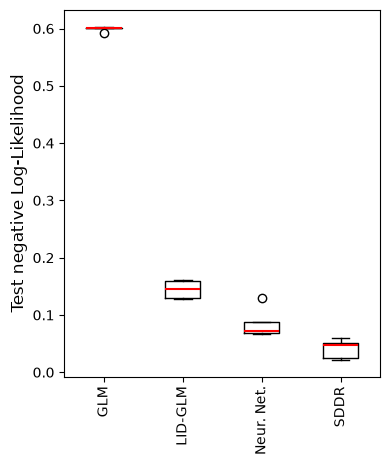

In [10]:
# First, we will visualize the performance across the different models:
fig, ax = plt.subplots(figsize=(4, 4.75))
models = ['GLM',
            'LID-GLM',
            'Neur. Net.', 
            'SDDR']
test_loglikes = [-all_metrics_df["test loglike_traditional"],
                    -all_metrics_df["test loglike_lid_glm_large_lip"],
                    -all_metrics_df["test loglike_nn"],
                    -all_metrics_df["test loglike_sddr"]
                 ]
box = ax.boxplot(test_loglikes)
ax.set_ylabel('Test negative Log-Likelihood', fontsize=12)
ax.set_xticklabels(models, fontsize = 10, rotation=90, ha = "center")

for median in box['medians']:
    median.set(color='red', linewidth=1.5, linestyle="-")
fig.tight_layout()
plt.savefig(output_dir + "/stroke_test_loglike_comparison.pdf")

In [11]:
# we construct a table aggregating mean and std of the test log-likelihoods for each model:
summary_table = pd.DataFrame({
    "Model": models,
    "Mean Test Log-Likelihood": [all_metrics_df["test loglike_traditional"].mean(),
                                all_metrics_df["test loglike_lid_glm_large_lip"].mean(),
                                all_metrics_df["test loglike_nn"].mean(),
                                all_metrics_df["test loglike_sddr"].mean()],
    "Std Test Log-Likelihood": [all_metrics_df["test loglike_traditional"].std(),
                               all_metrics_df["test loglike_lid_glm_large_lip"].std(),
                               all_metrics_df["test loglike_nn"].std(),
                               all_metrics_df["test loglike_sddr"].std()]
})
print(summary_table)
summary_table.to_csv(output_dir + "/stroke_test_loglike_summary_table.csv", index=False)

        Model  Mean Test Log-Likelihood  Std Test Log-Likelihood
0         GLM                 -0.599656                 0.004329
1     LID-GLM                 -0.144525                 0.016170
2  Neur. Net.                 -0.085018                 0.026421
3        SDDR                 -0.040980                 0.017222


In [5]:
##################import and preprocess dataset:#####################
stroke = pd.read_csv("../Datasets/Diabetes, Hypertension and Stroke Prediction (open)/stroke_data.csv", sep=",")

#3 entries contain NA values for "sex", these are a negligible fraction of the dataset, so we will drop them
stroke = stroke.dropna()

#The columns "age", "bmi", "avg_glucose_level" are non binary

#column "age" has 111 unique values; seems suspicious: let's check the distribution

#Does the table contain negative values for age?

#Weirdly, yes. These will be dropped for now
stroke = stroke[stroke["age"]>=0]

target = np.array(stroke["stroke"])
covariates = stroke.drop(["stroke", "work_type"], axis=1)
X= covariates
target = target.astype(int)
covariates = np.array(covariates)
target = np.array(target)
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
util = ExtendedGLM_Utils()
eval_util = Extended_glm_eval_utils()
n_covariates = X.shape[1]


In [6]:
# For each split we will store the beta coefficients for the top n runs (measured by their validation loss in the result grid) both with and without PHO:
model_name = "ldglm"

# initialize the dataframes:
read_top_n = 20
beta_dataframe_top_n_runs = pd.DataFrame(columns = ["split", "type", "model_ranking", "bias"] + X.columns.tolist())
beta_dataframe_top_n_runs.set_index(["split", "type", "model_ranking"], inplace=True)

# We want to check the dependence of model performance on the allowed Lipschitz constant
# For this, we read all models from all splits, pool them by their allowed Lipschitz constant and do boxplots.
lipschitz_validation_performance_dict = {}
lipschitz_test_performance_dict = {}

beta_differences_dataframe = pd.DataFrame(columns = ["split", "type","bias"] + X.columns.tolist())
beta_differences_dataframe.set_index(["split", "type"], inplace=True)

best_results_metrics = []
best_results_configs= []
best_NLL_small_constant = []
best_NLL_fixed_beta = []

all_tested_model_configs = {}

# We iterate through all splits
for i, (train_index, test_index) in enumerate(kf.split(target)):
    actual_train_index, val_index = train_test_split(train_index, test_size=0.2, random_state=42)
    covariates_used = normalize_covariates(covariates, train_index)
    X_train_val, X_test = covariates_used[train_index, :], covariates_used[test_index, :]
    y_train_val, y_test = target[train_index], target[test_index]

    # load the result grid object for this split:
    result_grid = tune.Tuner.restore(os.path.join(ldglm_simulation_result_subdir, f"k_fold_performance_analysis_stroke_{model_name}_split_"+str(i+1)), trainable =train_set_split).get_results()

    # We iterate over the top n runs to store their beta coefficients both with and without PHO:
    result_index = 0
    for run in result_grid.get_dataframe(filter_metric="validation_loss", filter_mode = "min").sort_values(by="validation_loss", ascending=True).head(read_top_n).iterrows():
        run_id = run[0]
        # load the extended GLM model from the checkpoint:
        loaded_run_model = util.load_from_ray_checkpoint(result_grid[run_id].get_best_checkpoint(metric="validation_loss", mode="min"), artifact_dir=artifact_dir).eval()
        # read the beta coefficient vector without PHO and append to the dataframe:
        beta_no_pho = np.append(loaded_run_model.read_linear_bias(), loaded_run_model.read_linear_weights())
        beta_dataframe_top_n_runs.loc[(i, "no PHO", result_index),:] = beta_no_pho
        # read the beta coefficient vector with PHO and append to the dataframe:
        beta_with_pho = eval_util.custom_PHO(loaded_run_model, torch.tensor(X_train_val, dtype=torch.float32))[0]
        beta_dataframe_top_n_runs.loc[(i, "with PHO", result_index),:] = beta_with_pho
        result_index += 1

    # We want to check the dependence of model performance on the allowed Lipschitz constant.
    # We pool all splits together for this and consider all models from all splits - not just the best ones.

    best_result_df = result_grid.get_dataframe(filter_metric="validation_loss", filter_mode = "min")
    for lipschitz_constant in best_result_df["config/model_specifications/lipschitz_const"]:
        if lipschitz_constant not in lipschitz_validation_performance_dict.keys():
            lipschitz_validation_performance_dict[lipschitz_constant] = best_result_df[best_result_df["config/model_specifications/lipschitz_const"] == lipschitz_constant]["validation_loss"].to_list()
        else:
            lipschitz_validation_performance_dict[lipschitz_constant] = lipschitz_validation_performance_dict[lipschitz_constant] + \
                best_result_df[best_result_df["config/model_specifications/lipschitz_const"] == lipschitz_constant]["validation_loss"].to_list()

    # To make our plot more readable later, we only show the top 10 models in each split; also, we list test performance instead of validation loss.
    top_n_per_const = 10
    for key in lipschitz_validation_performance_dict.keys():
        if key not in lipschitz_test_performance_dict.keys():
            lipschitz_test_performance_dict[key] = []
        filtered_df = best_result_df[best_result_df["config/model_specifications/lipschitz_const"] == key].sort_values(by="validation_loss", ascending=True).head(top_n_per_const)
        for run_id, run in filtered_df.iterrows():
            # load the extended GLM model from the checkpoint:
            loaded_run_model = util.load_from_ray_checkpoint(result_grid[run_id].get_best_checkpoint(metric="validation_loss", mode="min"), artifact_dir=artifact_dir).eval()
            # independently compute test log-likelihood:
            test_log_like = loaded_run_model.log_like_obs(exog = torch.tensor(X_test, dtype=torch.float32),endog= torch.tensor(y_test, dtype=torch.float32)).detach().cpu().numpy().mean()
            lipschitz_test_performance_dict[key].append(-test_log_like.item())


    # we want to find the best model with a small Lipschitz constant and the best model with a fixed beta for comparison:
    small_lipschitz_constant = np.sort(np.array(list(lipschitz_validation_performance_dict.keys())))[3]
    id_best_small_constant = best_result_df[best_result_df["config/model_specifications/lipschitz_const"] == small_lipschitz_constant].sort_values(by="validation_loss", ascending=True).head(1).index[0]
    loaded_small_constant_model = util.load_from_ray_checkpoint(result_grid[id_best_small_constant].get_best_checkpoint(metric="validation_loss", mode="min"), artifact_dir=artifact_dir).eval()
    small_constant_test_log_like = loaded_small_constant_model.log_like_obs(exog = torch.tensor(X_test, dtype=torch.float32),endog= torch.tensor(y_test, dtype=torch.float32)).detach().cpu().numpy().mean()
    best_NLL_small_constant.append(-small_constant_test_log_like.item())
    id_best_fixed_beta = best_result_df[best_result_df["config/model_specifications/part_to_train"] == "network"].sort_values(by="validation_loss", ascending=True).head(1).index[0]
    loaded_fixed_beta_model = util.load_from_ray_checkpoint(result_grid[id_best_fixed_beta].get_best_checkpoint(metric="validation_loss", mode="min"), artifact_dir=artifact_dir).eval()
    fixed_beta_test_log_like = loaded_fixed_beta_model.log_like_obs(exog = torch.tensor(X_test, dtype=torch.float32),endog= torch.tensor(y_test, dtype=torch.float32)).detach().cpu().numpy().mean()
    best_NLL_fixed_beta.append(-fixed_beta_test_log_like.item())


    # for each split, we want to find the hyperparameters of the best performing LiD-GLM model
    best_result = result_grid.get_best_result(metric="validation_loss", mode="min", scope = "all")
    best_results_metrics.append(best_result.metrics)
    best_results_configs.append(best_result.config["model_specifications"])

    if len(all_tested_model_configs.keys()) == 0:
        for key in best_result.config["model_specifications"].keys():
            all_tested_model_configs[key] = set([])

    for key in all_tested_model_configs.keys():
        all_tested_model_configs[key] = all_tested_model_configs[key].union(set(best_result_df["config/model_specifications/"+key].unique()))

TypeError: code() argument 13 must be str, not int

In [ ]:
# First, we will vizualize the performance across the different models:
fig, ax = plt.subplots(figsize=(4, 4.75))
models = ['GLM',            
            f"LiD-GLM \n $L_p^b = {np.round(small_lipschitz_constant-1, 2)}$",
            f"LiD-GLM \n fixed beta",
            'LID-GLM',
            'Neur. Net.', 
            'SDDR']
test_loglikes = [-all_metrics_df["test loglike_traditional"],
                    best_NLL_small_constant,
                    best_NLL_fixed_beta,
                    -all_metrics_df["test loglike_lid_glm_large_lip"],
                    -all_metrics_df["test loglike_nn"],
                    -all_metrics_df["test loglike_sddr"]
                 ]
box = ax.boxplot(test_loglikes)
ax.set_ylabel('Test negative Log-Likelihood', fontsize=12)
ax.set_xticklabels(models, fontsize = 10, rotation=90, ha = "center")

for median in box['medians']:
    median.set(color='black', linewidth=1.5, linestyle="-")
fig.tight_layout()
plt.savefig(output_dir + "/stroke_test_loglike_comparison.pdf")

In [ ]:
# we convert the data types from numpy to base Python types and also round to 3 digits
for key, config_set in all_tested_model_configs.items():
    for item in config_set:
        if isinstance(item, np.integer):
            config_set.remove(item)
            config_set.add(int(item))
        elif isinstance(item, np.floating):
            config_set.remove(item)
            config_set.add(round(float(item), 3))
    # we also sort the sets for better readability
    all_tested_model_configs[key] = sorted(list(config_set))

with open(ldglm_simulation_result_subdir + f"/stroke_all_tested_model_hyperparameter_configs_{model_name}.json", "w") as f:
    json.dump({key: list(value) for key, value in all_tested_model_configs.items()}, f)


In [ ]:
all_tested_model_configs

In [ ]:
best_result_configs_df = pd.DataFrame(best_results_configs)
print(best_result_configs_df)
best_result_configs_df.to_csv(ldglm_simulation_result_subdir + "/stroke_best_hyperparams_"+ model_name + ".csv")

In [ ]:
# we do vertical boxplots of the coeffs with/without PHO with separate subplots for each covariate 
# in each subplot, we have two groups of plots: with/without PHO, each group has 5 plots, colored by split
n_covariates_per_row = 4
n_rows = math.ceil(n_covariates / n_covariates_per_row)
fig, axs = plt.subplots(n_rows, n_covariates_per_row, figsize = (2.3*(n_covariates_per_row+1), 3*n_rows))
# we have a prime number of covariates, so some subplots will be empty and deleted:
number_of_empty_plots = n_covariates_per_row * n_rows - n_covariates
for empty_plot_index in range(number_of_empty_plots):
    fig.delaxes(axs[-1, -1 - empty_plot_index])

seaborn_df = pd.melt(beta_dataframe_top_n_runs.reset_index(), id_vars=["split", "type", "model_ranking"], value_vars=X.columns.tolist(), var_name="covariate", value_name="coefficient")

covariates = X.columns.tolist()
# we rename the types to PHO and No PHO for better readability in the plot
seaborn_df["type"] = seaborn_df["type"].replace({"no PHO": "No PHO", "with PHO": "PHO"})
# we rename the column "split" to "Split" for better readability in the plot
seaborn_df.columns = seaborn_df.columns.str.replace("split", "Split")

for i in range(n_covariates):
    used_dataframe = seaborn_df[seaborn_df["covariate"]==covariates[i]]
    legend = False if i < n_covariates-1  else "auto"
    ax = axs[i//n_covariates_per_row, i%n_covariates_per_row]
    sns.boxplot(x="type", y="coefficient", data= used_dataframe, hue="Split", ax = ax, palette="rocket", legend =legend)
    #chnage legend position to be right outside axis
    if legend:
        ax.legend(title="Split", loc=(1.01, 0.))

    ax.set_xlabel("")
    if i%n_covariates_per_row > 0:
        ax.set_ylabel("")
    else:
        ax.set_ylabel("Coefficient value", fontsize = 12)
    ax.set_title(covariates[i], font ="serif", fontweight ="bold", fontsize = 12)


fig.tight_layout()
fig.savefig(output_dir+f"/pho_beta_coefficients_boxplots_top{read_top_n}_{model_name}_split1to5_stroke.pdf")